In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)


Train shape: (60000, 28, 28) (60000,)
Test shape : (10000, 28, 28) (10000,)


In [3]:
x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784) / 255.0

print("After reshape train:", x_train.shape)
print("After reshape test :", x_test.shape)


After reshape train: (60000, 784)
After reshape test : (10000, 784)


In [4]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()


c:\Users\samve\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [6]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9261 - loss: 0.2532 - val_accuracy: 0.9683 - val_loss: 0.1074
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9685 - loss: 0.1051 - val_accuracy: 0.9705 - val_loss: 0.1029
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9774 - loss: 0.0725 - val_accuracy: 0.9760 - val_loss: 0.0764
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9785 - val_loss: 0.0750
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9861 - loss: 0.0436 - val_accuracy: 0.9733 - val_loss: 0.1030
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9782 - val_loss: 0.0793
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9900 - loss: 0.0297 - val_accuracy: 0.9798 - val_loss: 0.0766
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9924 - loss: 0.0230 

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9774 - loss: 0.0851
Test Loss: 0.08509358763694763
Test Accuracy: 0.977400004863739


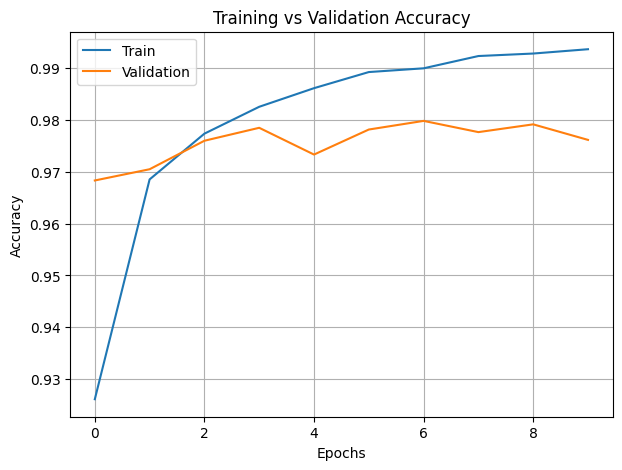

In [8]:
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()
plt.show()


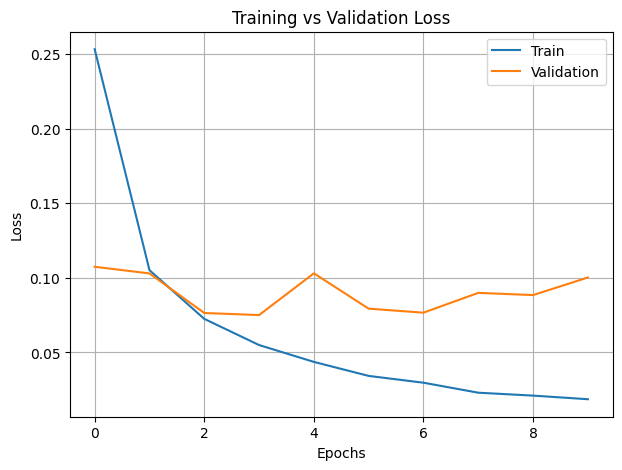

In [9]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid()
plt.show()


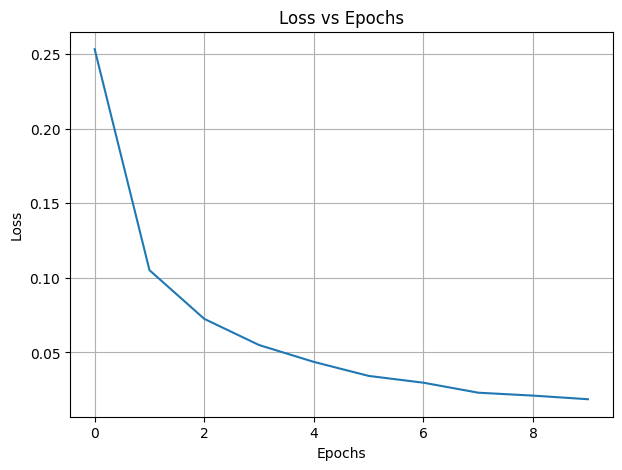

In [10]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()


In [11]:
print("OBSERVATIONS:")
print("1. Model achieved good accuracy (normally 97% - 98%).")
print("2. Validation accuracy increases and stabilizes after some epochs.")
print("3. If training accuracy increases but validation accuracy stops, overfitting may occur.")
print("4. Increasing epochs beyond 10 may not improve much.")
print("5. Hidden layers improve learning but increase computation time.")


OBSERVATIONS:
1. Model achieved good accuracy (normally 97% - 98%).
2. Validation accuracy increases and stabilizes after some epochs.
3. If training accuracy increases but validation accuracy stops, overfitting may occur.
4. Increasing epochs beyond 10 may not improve much.
5. Hidden layers improve learning but increase computation time.
